In [1]:
# CELDA 1 — Imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

print("Imports OK ✅")

Imports OK ✅


In [2]:
# CELDA 2 — Configuración
# =====================================================================
I_START_REF = 2900
I_END_REF   = None   # None = hasta el final de REF_FILE
REF_FILE    = "esc_2_4700_064_85_dd.npy"   # archivo de referencia espacial

ARCHIVOS = [
    "esc_2_4700_064_85_dd.npy",
    "esc_2_4700_064_95_dd.npy",
    "esc_2_4700_072_85_dd.npy",
    "esc_2_4700_072_95_dd.npy",
    "esc_2_5300_064_85_dd.npy",
    "esc_2_5300_064_95_dd.npy",
    "esc_2_5300_072_85_dd.npy",
    "esc_2_5300_072_95_dd.npy",
]
# =====================================================================
print(f"Referencia espacial: {REF_FILE}")
print(f"Ventana en ref:      [{I_START_REF} → FIN]")
print(f"Experimentos DD — Escenario 2: {len(ARCHIVOS)}")

Referencia espacial: esc_2_4700_064_85_dd.npy
Ventana en ref:      [2900 → FIN]
Experimentos DD — Escenario 2: 8


In [3]:
# CELDA 3 — Carga, matching espacial y métricas
def parse_nombre(f):
    partes = f.replace(".npy", "").replace("_fail", "").split("_")
    return {
        "masa":     int(partes[2]),
        "friccion": int(partes[3]) / 100,
        "vel":      int(partes[4]),
        "ctrl":     partes[5],
    }

def calcular_metricas(sim, i0, i1):
    i1 = min(i1, len(sim["x"]))
    cte   = sim["crosstrack_error"][i0:i1]
    steer = sim["steer_rad"][i0:i1]
    speed = sim["speed"][i0:i1] * 3.6
    return {
        "rmse_cte": float(np.sqrt(np.mean(cte**2))),
        "mae_cte":  float(np.mean(np.abs(cte))),
        "e_max":    float(np.max(np.abs(cte))),
        "tv_delta": float(np.sum(np.abs(np.diff(steer)))),
        "v_media":  float(np.mean(speed)),
        "v_min":    float(np.min(speed)),
        "pasos":    i1 - i0,
    }

def encontrar_idx_espacial(sim, x_ref, y_ref, desde=0):
    dists = np.sqrt((sim["x"][desde:] - x_ref)**2 + (sim["y"][desde:] - y_ref)**2)
    return desde + int(np.argmin(dists))

# Puntos espaciales de referencia
ref_data = np.load(REF_FILE, allow_pickle=True).item()
x0_ref   = float(ref_data["x"][I_START_REF])
y0_ref   = float(ref_data["y"][I_START_REF])
x1_ref   = float(ref_data["x"][-1 if I_END_REF is None else I_END_REF])
y1_ref   = float(ref_data["y"][-1 if I_END_REF is None else I_END_REF])

print(f"Punto inicio ref: ({x0_ref:.2f}, {y0_ref:.2f})")
print(f"Punto fin   ref: ({x1_ref:.2f}, {y1_ref:.2f})\n")

resultados = []
sims = {}

for f in ARCHIVOS:
    info = parse_nombre(f)
    sim  = np.load(f, allow_pickle=True).item()
    i0   = encontrar_idx_espacial(sim, x0_ref, y0_ref)
    i1   = encontrar_idx_espacial(sim, x1_ref, y1_ref, desde=i0)
    met  = calcular_metricas(sim, i0, i1)
    resultados.append({**info, **met, "archivo": f, "i_start": i0, "i_end": i1})
    sims[f] = sim

print(f"Cargados: {len(resultados)} experimentos ✅")
print(f"\n{'Archivo':<45} {'i_start':>8} {'i_end':>7} {'pasos':>7}")
print("─" * 72)
for r in resultados:
    print(f"  {r['archivo']:<43} {r['i_start']:>8} {r['i_end']:>7} {r['pasos']:>7}")

Punto inicio ref: (2.43, -300.40)
Punto fin   ref: (-8.87, 41.00)

Cargados: 8 experimentos ✅

Archivo                                        i_start   i_end   pasos
────────────────────────────────────────────────────────────────────────
  esc_2_4700_064_85_dd.npy                        2900    3195     295
  esc_2_4700_064_95_dd.npy                        2674    2938     264
  esc_2_4700_072_85_dd.npy                        2900    3195     295
  esc_2_4700_072_95_dd.npy                        2674    2938     264
  esc_2_5300_064_85_dd.npy                        2937    3232     295
  esc_2_5300_064_95_dd.npy                        2717    2982     265
  esc_2_5300_072_85_dd.npy                        2937    3232     295
  esc_2_5300_072_95_dd.npy                        2716    2981     265


In [4]:
# CELDA 4 — Tabla resumen de métricas
header = f"{'Masa':>6} {'μ':>5} {'V(km/h)':>8} | {'RMSE_cte':>9} {'E_max':>8} {'MAE_cte':>8} {'TV_δ':>9} | {'V_med':>6} {'V_min':>6}"
sep    = "─" * len(header)

print(sep)
print(header)
print(sep)

for r in sorted(resultados, key=lambda x: (x["vel"], x["masa"], x["friccion"])):
    print(f"{r['masa']:>6} {r['friccion']:>5.2f} {r['vel']:>8} | "
          f"{r['rmse_cte']:>9.4f} {r['e_max']:>8.4f} {r['mae_cte']:>8.4f} "
          f"{r['tv_delta']:>9.4f} | {r['v_media']:>6.1f} {r['v_min']:>6.1f}")

print(sep)

rmse_vals = [r["rmse_cte"] for r in resultados]
emax_vals = [r["e_max"]    for r in resultados]
tv_vals   = [r["tv_delta"] for r in resultados]
print(f"\n  RMSE_cte → min={min(rmse_vals):.4f}  max={max(rmse_vals):.4f}  media={np.mean(rmse_vals):.4f}")
print(f"  E_max    → min={min(emax_vals):.4f}  max={max(emax_vals):.4f}  media={np.mean(emax_vals):.4f}")
print(f"  TV_δ     → min={min(tv_vals):.4f}  max={max(tv_vals):.4f}  media={np.mean(tv_vals):.4f}")

─────────────────────────────────────────────────────────────────────────────
  Masa     μ  V(km/h) |  RMSE_cte    E_max  MAE_cte      TV_δ |  V_med  V_min
─────────────────────────────────────────────────────────────────────────────
  4700  0.64       85 |    0.2927   0.7832   0.2104    5.2797 |   84.3   82.7
  4700  0.72       85 |    0.2927   0.7830   0.2104    5.2784 |   84.3   82.7
  5300  0.64       85 |    0.2927   0.7983   0.2102    5.2951 |   84.2   82.6
  5300  0.72       85 |    0.2925   0.7827   0.2102    5.2625 |   84.2   82.6
  4700  0.64       95 |    0.3661   0.9920   0.2857    5.9469 |   94.1   92.5
  4700  0.72       95 |    0.3662   0.9922   0.2857    5.9505 |   94.1   92.5
  5300  0.64       95 |    0.3634   0.9824   0.2833    5.9873 |   93.9   92.3
  5300  0.72       95 |    0.3660   0.9768   0.2850    5.9921 |   93.9   92.3
─────────────────────────────────────────────────────────────────────────────

  RMSE_cte → min=0.2925  max=0.3662  media=0.3290
  E_max    → 

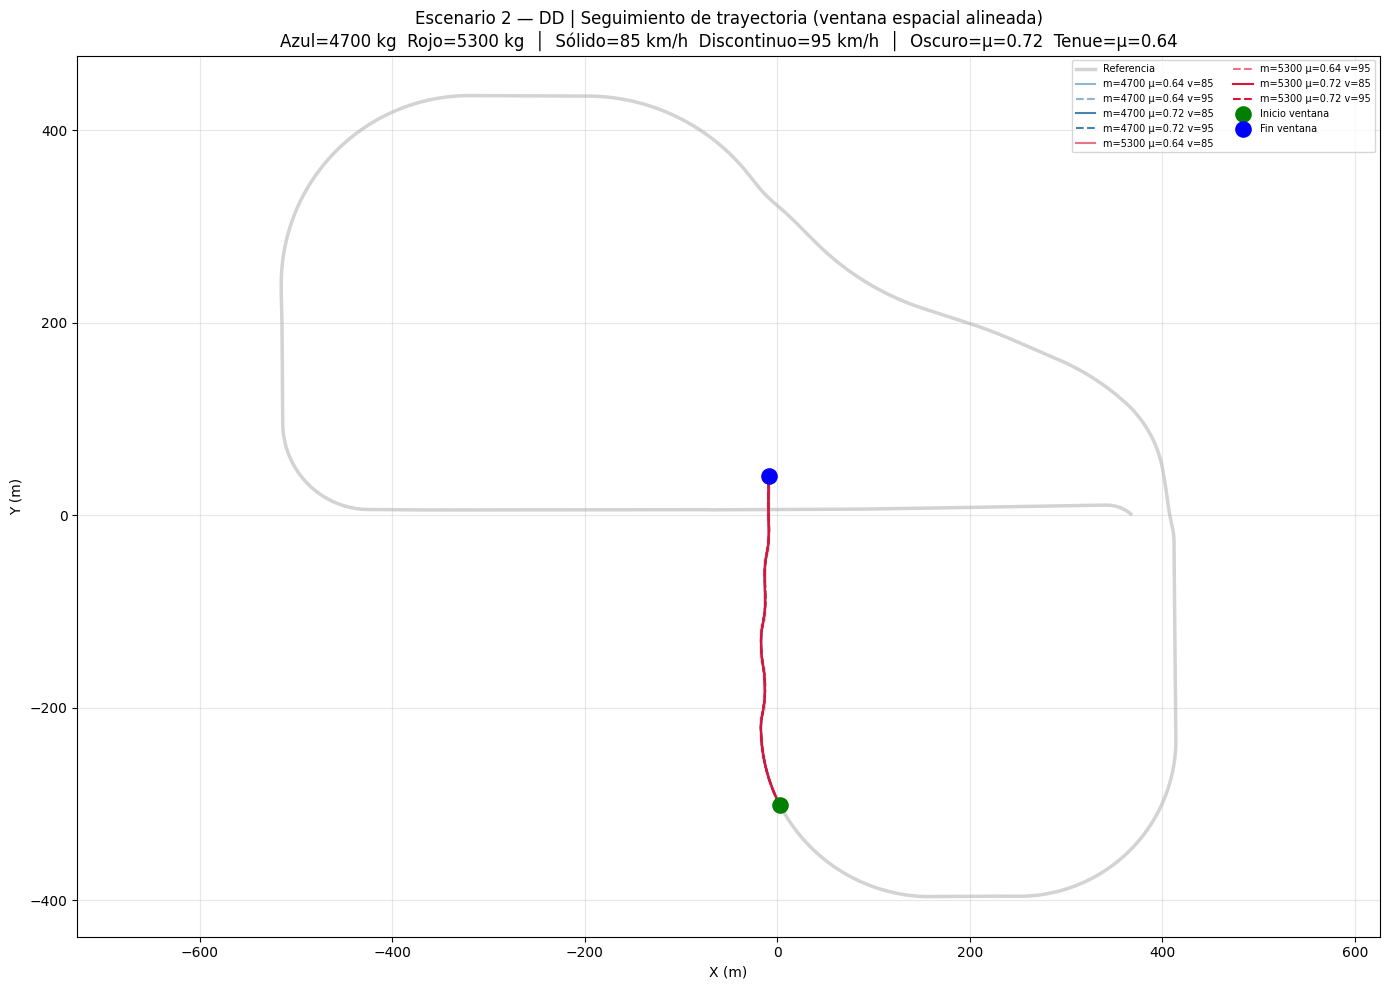

Guardado ✅


In [5]:
# CELDA 5 — Seguimiento de trayectoria (ventana espacialmente alineada)
TRAJ_FILE = "traj_escenario2_v85.npy"
DECIM_REF = 20

traj_ref = np.load(TRAJ_FILE, allow_pickle=True).item()

colores = {4700: "steelblue", 5300: "crimson"}
estilos = {85: "-", 95: "--"}
alphas  = {0.64: 0.6, 0.72: 1.0}

fig, ax = plt.subplots(figsize=(14, 10))

ax.plot(traj_ref["x"][::DECIM_REF], traj_ref["y"][::DECIM_REF],
        color="lightgray", linewidth=2.5, zorder=1, label="Referencia")

all_x, all_y = [], []
for r in sorted(resultados, key=lambda x: (x["masa"], x["friccion"], x["vel"])):
    sim = sims[r["archivo"]]
    x_v = sim["x"][r["i_start"]:r["i_end"]]
    y_v = sim["y"][r["i_start"]:r["i_end"]]
    all_x.extend(x_v); all_y.extend(y_v)
    label = f"m={r['masa']} μ={r['friccion']:.2f} v={r['vel']}"
    ax.plot(x_v, y_v,
            color=colores[r["masa"]], linestyle=estilos[r["vel"]],
            alpha=alphas[r["friccion"]], linewidth=1.5, label=label, zorder=5)

ax.scatter([x0_ref], [y0_ref], s=120, c="green", zorder=10, label="Inicio ventana")
ax.scatter([x1_ref], [y1_ref], s=120, c="blue",  zorder=10, label="Fin ventana")

pad = 8
ax.set_xlim(min(all_x) - pad, max(all_x) + pad)
ax.set_ylim(min(all_y) - pad, max(all_y) + pad)

ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)")
ax.set_title("Escenario 2 — DD | Seguimiento de trayectoria (ventana espacial alineada)\n"
             "Azul=4700 kg  Rojo=5300 kg  │  Sólido=85 km/h  Discontinuo=95 km/h  │  Oscuro=μ=0.72  Tenue=μ=0.64")
ax.axis("equal"); ax.grid(True, alpha=0.3); ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig("esc2_dd_traj_seguimiento.png", dpi=200, bbox_inches="tight")
plt.show()
print("Guardado ✅")

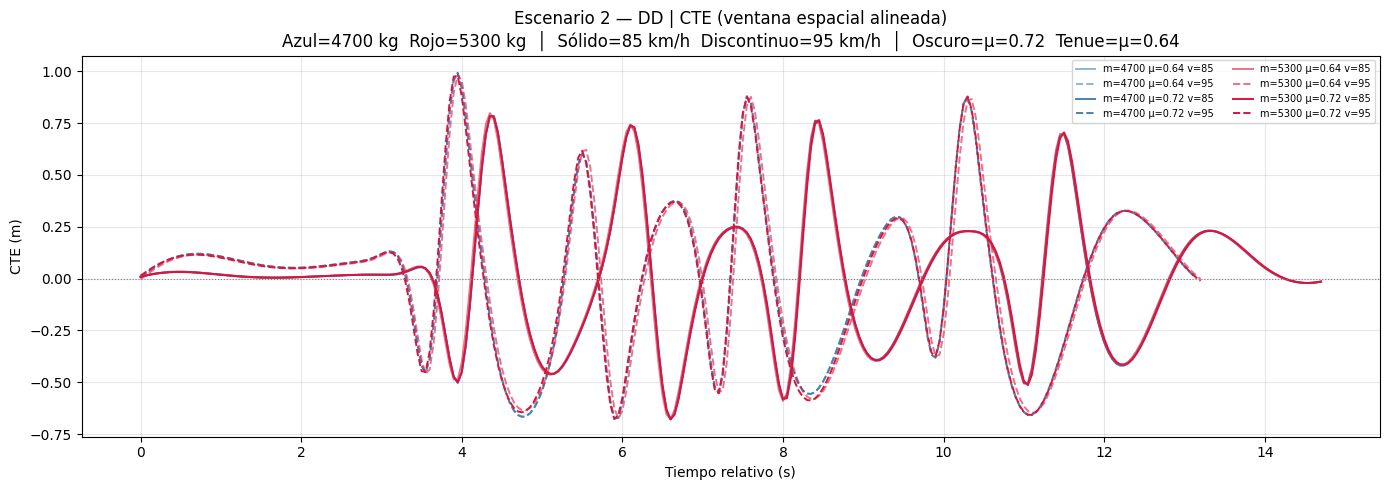

Guardado ✅


In [6]:
# CELDA 6 — CTE superpuestas (mismo segmento espacial)
fig, ax = plt.subplots(figsize=(14, 5))

for r in sorted(resultados, key=lambda x: (x["masa"], x["friccion"], x["vel"])):
    sim = sims[r["archivo"]]
    i0, i1 = r["i_start"], r["i_end"]
    dt  = float(np.mean(np.diff(sim["time"])))
    t   = np.arange(i1 - i0) * dt
    cte = sim["crosstrack_error"][i0:i1]
    label = f"m={r['masa']} μ={r['friccion']:.2f} v={r['vel']}"
    ax.plot(t, cte,
            color=colores[r["masa"]], linestyle=estilos[r["vel"]],
            alpha=alphas[r["friccion"]], linewidth=1.4, label=label)

ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
ax.set_xlabel("Tiempo relativo (s)")
ax.set_ylabel("CTE (m)")
ax.set_title("Escenario 2 — DD | CTE (ventana espacial alineada)\n"
             "Azul=4700 kg  Rojo=5300 kg  │  Sólido=85 km/h  Discontinuo=95 km/h  │  Oscuro=μ=0.72  Tenue=μ=0.64")
ax.legend(fontsize=7, ncol=2, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("esc2_dd_cte_overlay.png", dpi=200, bbox_inches="tight")
plt.show()
print("Guardado ✅")

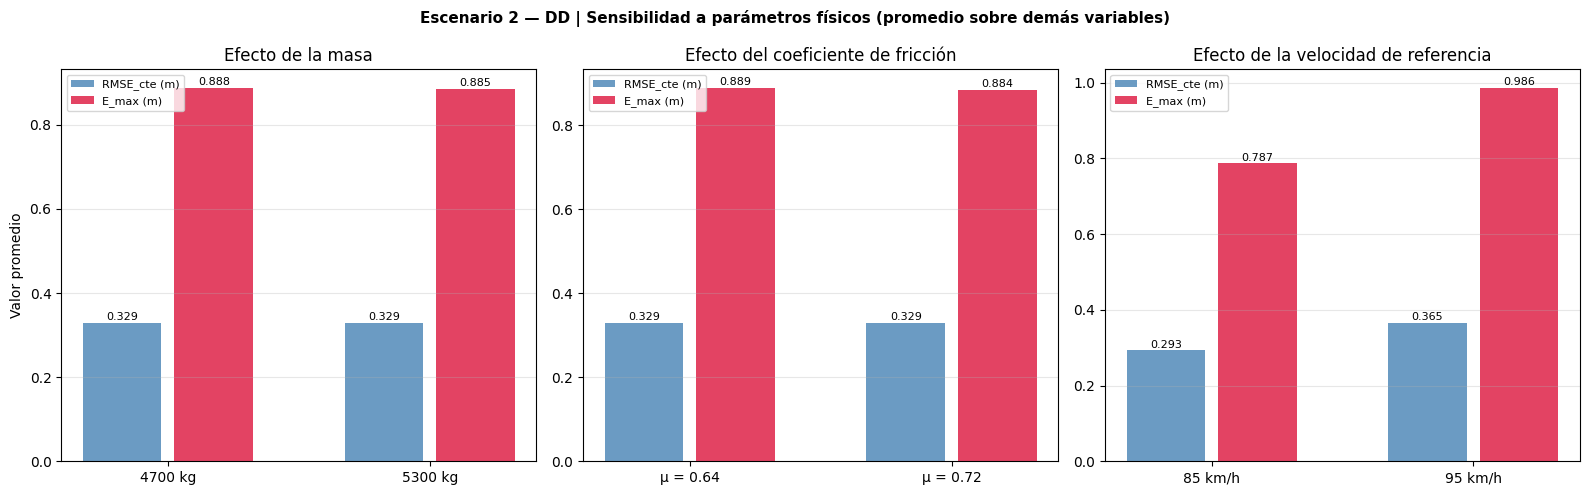

Guardado ✅


In [7]:
# CELDA 6 — Efecto de cada variable sobre RMSE_cte y E_max
def filtrar(resultados, **kwargs):
    return [r for r in resultados if all(r[k] == v for k, v in kwargs.items())]

masas       = [4700, 5300]
fricciones  = [0.64, 0.72]
velocidades = [85, 95]
metricas_plot = [("rmse_cte", "RMSE_cte (m)"), ("e_max", "E_max (m)")]
bcolors = ["steelblue", "crimson"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# — Efecto masa
ax = axes[0]
for mi, met in enumerate(metricas_plot):
    vals = [np.mean([r[met[0]] for r in filtrar(resultados, masa=m)]) for m in masas]
    x = np.array([0, 1]) + mi * 0.35
    bars = ax.bar(x, vals, width=0.3, color=bcolors[mi], alpha=0.8, label=met[1])
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f"{v:.3f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks([0.175, 1.175]); ax.set_xticklabels(["4700 kg", "5300 kg"])
ax.set_title("Efecto de la masa"); ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
ax.set_ylabel("Valor promedio")

# — Efecto fricción
ax = axes[1]
for mi, met in enumerate(metricas_plot):
    vals = [np.mean([r[met[0]] for r in filtrar(resultados, friccion=mu)]) for mu in fricciones]
    x = np.array([0, 1]) + mi * 0.35
    bars = ax.bar(x, vals, width=0.3, color=bcolors[mi], alpha=0.8, label=met[1])
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f"{v:.3f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks([0.175, 1.175]); ax.set_xticklabels(["μ = 0.64", "μ = 0.72"])
ax.set_title("Efecto del coeficiente de fricción"); ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

# — Efecto velocidad
ax = axes[2]
for mi, met in enumerate(metricas_plot):
    vals = [np.mean([r[met[0]] for r in filtrar(resultados, vel=v)]) for v in velocidades]
    x = np.array([0, 1]) + mi * 0.35
    bars = ax.bar(x, vals, width=0.3, color=bcolors[mi], alpha=0.8, label=met[1])
    for bar, v2 in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f"{v2:.3f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks([0.175, 1.175]); ax.set_xticklabels(["85 km/h", "95 km/h"])
ax.set_title("Efecto de la velocidad de referencia"); ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

fig.suptitle("Escenario 2 — DD | Sensibilidad a parámetros físicos (promedio sobre demás variables)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("esc2_dd_sensibilidad.png", dpi=200, bbox_inches="tight")
plt.show()
print("Guardado ✅")

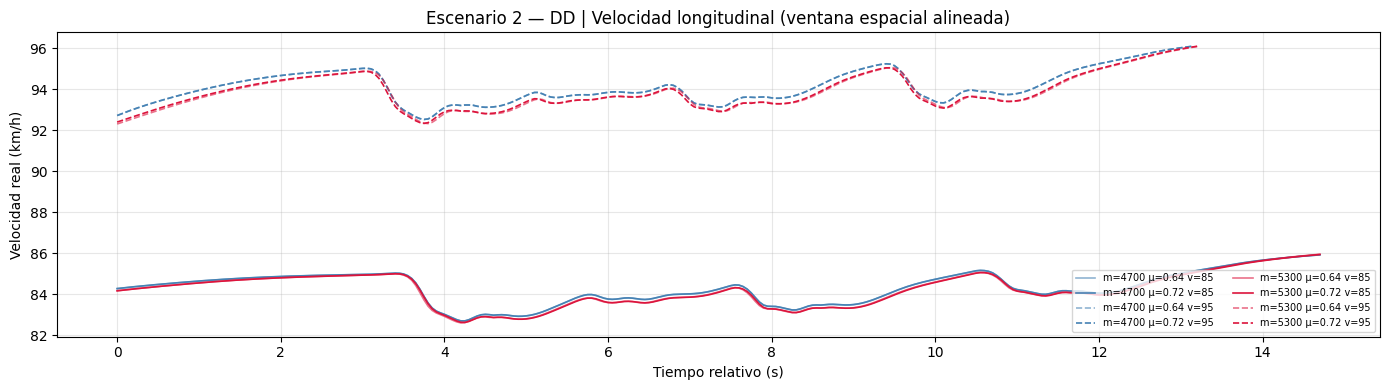

Guardado ✅


In [8]:
# CELDA 8 — Velocidad superpuesta (mismo segmento espacial)
fig, ax = plt.subplots(figsize=(14, 4))

for r in sorted(resultados, key=lambda x: (x["masa"], x["vel"])):
    sim = sims[r["archivo"]]
    i0, i1 = r["i_start"], r["i_end"]
    dt  = float(np.mean(np.diff(sim["time"])))
    t   = np.arange(i1 - i0) * dt
    v   = sim["speed"][i0:i1] * 3.6
    label = f"m={r['masa']} μ={r['friccion']:.2f} v={r['vel']}"
    ax.plot(t, v,
            color=colores[r["masa"]], linestyle=estilos[r["vel"]],
            alpha=alphas[r["friccion"]], linewidth=1.2, label=label)

ax.set_xlabel("Tiempo relativo (s)")
ax.set_ylabel("Velocidad real (km/h)")
ax.set_title("Escenario 2 — DD | Velocidad longitudinal (ventana espacial alineada)")
ax.legend(fontsize=7, ncol=2, loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("esc2_dd_velocidad.png", dpi=200, bbox_inches="tight")
plt.show()
print("Guardado ✅")